In [1]:
!pip install selenium webdriver-manager pandas openpyxl

In [19]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()))
driver.maximize_window()
driver.get("https://www.nykaa.com/makeup/c/12")

In [3]:
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()))

url = "https://www.nykaa.com/makeup/c/12"

driver.get(url)

driver.maximize_window()

time.sleep(8)

In [7]:
for i in range(5):
    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
    time.sleep(3)

In [6]:
products = driver.find_elements(By.CSS_SELECTOR, "div.css-xrzmfa")
print("Total Products:", len(products))

Total Products: 0


In [8]:
print(driver.title)

Buy Makeup Products Online For Everyday Effortless Look


In [9]:
print(driver.current_url)

https://www.nykaa.com/makeup/c/12


In [10]:
all_divs = driver.find_elements(By.TAG_NAME, "div")
print("Total divs:", len(all_divs))

Total divs: 781


In [11]:
products = driver.find_elements(By.CSS_SELECTOR, "a[href*='/p/']")
print("Product Links:", len(products))

Product Links: 36


In [12]:
first_product = products[0]
print(first_product.text)

Flicka Silk Touch 3-In-1 Moisturizer Primer And Sun Care Der...
₹899
₹809
10% Off
Regular price ₹899. Discounted price ₹809. 10% Off.
Extra 4% Off
( 15405 )


In [13]:
print(first_product.get_attribute("outerHTML"))

<a target="_blank" rel="noopener noreferrer" class="css-qlopj4" href="/flicka-silk-touch-milk-cream-concentrate-primer-moisturizer/p/17051860?productId=17051860&amp;pps=1"><div class="css-43m2vm"><img src="https://images-static.nykaa.com/media/catalog/product/tr:w-220,h-220,cm-pad_resize/3/e/3ea706dFLIAA00000131_01.jpg" alt="Flicka Silk Touch 3-In-1 Moisturizer Primer And Sun Care Dermatologically Tested And Minimize Pores" class="css-11gn9r6"></div><div class="css-1rd7vky"><h2 class="css-xrzmfa">Flicka Silk Touch 3-In-1 Moisturizer Primer And Sun Care Der...</h2><div aria-hidden="true" class="css-1d0jf8e"><span class="css-17x46n5"><span>₹899</span></span><span class="css-111z9ua">₹809</span><span class="css-cjd9an">10% Off</span></div><span class="css-1yjfidh">Regular price ₹899. Discounted price ₹809. 10% Off.</span><p color="0" class="css-1kzcg63">Extra 4% Off</p><div aria-label="4 out of 5 star rating" class="css-wskh5y"><span class="star-wrap" aria-hidden="true"><svg xmlns="http:/

In [14]:
from bs4 import BeautifulSoup

html = first_product.get_attribute("outerHTML")

soup = BeautifulSoup(html, "html.parser")

print(soup.prettify())

<a class="css-qlopj4" href="/flicka-silk-touch-milk-cream-concentrate-primer-moisturizer/p/17051860?productId=17051860&amp;pps=1" rel="noopener noreferrer" target="_blank">
 <div class="css-43m2vm">
  <img alt="Flicka Silk Touch 3-In-1 Moisturizer Primer And Sun Care Dermatologically Tested And Minimize Pores" class="css-11gn9r6" src="https://images-static.nykaa.com/media/catalog/product/tr:w-220,h-220,cm-pad_resize/3/e/3ea706dFLIAA00000131_01.jpg"/>
 </div>
 <div class="css-1rd7vky">
  <h2 class="css-xrzmfa">
   Flicka Silk Touch 3-In-1 Moisturizer Primer And Sun Care Der...
  </h2>
  <div aria-hidden="true" class="css-1d0jf8e">
   <span class="css-17x46n5">
    <span>
     ₹899
    </span>
   </span>
   <span class="css-111z9ua">
    ₹809
   </span>
   <span class="css-cjd9an">
    10% Off
   </span>
  </div>
  <span class="css-1yjfidh">
   Regular price ₹899. Discounted price ₹809. 10% Off.
  </span>
  <p class="css-1kzcg63" color="0">
   Extra 4% Off
  </p>
  <div aria-label="4 out

In [32]:
from bs4 import BeautifulSoup

product_name = []
original_price = []
discounted_price = []
discount = []
reviews = []

for product in products:
    soup = BeautifulSoup(product.get_attribute("outerHTML"), "html.parser")

    # Product Name
    try:
        name = soup.find("h2", class_="css-xrzmfa").text.strip()
    except:
        name = ""

    # Original Price
    try:
        org = soup.find("span", class_="css-17x46n5").text.strip()
    except:
        org = ""

    # Discounted Price
    try:
        dis = soup.find("span", class_="css-111z9ua").text.strip()
    except:
        dis = ""

    # Discount %
    try:
        off = soup.find("span", class_="css-cjd9an").text.strip()
    except:
        off = ""

    # Reviews
    try:
        rev = soup.find("span", class_="css-1qbvrhp").text.strip()
    except:
        rev = ""

    product_name.append(name)
    original_price.append(org)
    discounted_price.append(dis)
    discount.append(off)
    reviews.append(rev)

In [33]:
df = pd.DataFrame({
    "Product Name": product_name,
    "Original Price": original_price,
    "Discounted Price": discounted_price,
    "Discount": discount,
    "Reviews": reviews
})

In [52]:
# Remove rows where Product Name is empty
df = df[df["Product Name"].str.strip() != ""]

# Reset index
df = df.reset_index(drop=True)

print(df.shape)
print(df.head())

(20, 5)
                                                      Product Name  \
0  Flicka Silk Touch 3-In-1 Moisturizer Primer And Sun Care Der...   
1  L'Oreal Paris Infallible 3-Second Setting Spray, 36hr Long L...   
2         ETUDE Dear Darling Water Gel Lip and Cheek Tint Lipstick   
3  M.A.C Studio Fix Fluid SPF 15 Soft Matte Foundation With Hya...   
4                Charlotte Tilbury Airbrush Flawless Setting Spray   

  Original Price Discounted Price Discount     Reviews  
0           ₹899             ₹809  10% Off   ( 15405 )  
1           ₹799             ₹719  10% Off    ( 7746 )  
2           ₹450             ₹405  10% Off   ( 22608 )  
3          ₹4000            ₹3400  15% Off  ( 686256 )  
4                           ₹3950            ( 10926 )  


In [53]:
df.to_csv("Nykaa_Beauty_Products.csv", index=False)

In [54]:
print(len(df))

20


In [77]:
print(df.head())
print(df.shape)

                                                      Product Name  \
0  Flicka Silk Touch 3-In-1 Moisturizer Primer And Sun Care Der...   
1  L'Oreal Paris Infallible 3-Second Setting Spray, 36hr Long L...   
2         ETUDE Dear Darling Water Gel Lip and Cheek Tint Lipstick   
3  M.A.C Studio Fix Fluid SPF 15 Soft Matte Foundation With Hya...   
4                Charlotte Tilbury Airbrush Flawless Setting Spray   

  Original Price Discounted Price     Discount     Reviews  
0           ₹899             ₹809      10% Off   ( 15405 )  
1           ₹799             ₹719      10% Off    ( 7746 )  
2           ₹450             ₹405      10% Off   ( 22608 )  
3          ₹4000            ₹3400      15% Off  ( 686256 )  
4                           ₹3950  No Discount   ( 10926 )  
(20, 5)


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Product Name      36 non-null     object
 1   Original Price    36 non-null     object
 2   Discounted Price  36 non-null     object
 3   Discount          36 non-null     object
 4   Reviews           36 non-null     object
dtypes: object(5)
memory usage: 1.5+ KB


In [36]:
df.isnull().sum()

Product Name        0
Original Price      0
Discounted Price    0
Discount            0
Reviews             0
dtype: int64

In [37]:
df.to_csv("Nykaa_Beauty_Products.csv", index=False)
print("Dataset Saved Successfully!")

Dataset Saved Successfully!


In [38]:
df.describe(include='all')

,Product Name,Original Price,Discounted Price,Discount,Reviews
count,36,36,36,36,36
unique,21,13,21,7,21
top,,,,,
freq,16,24,16,24,16


In [40]:
df.sample(5)

,Product Name,Original Price,Discounted Price,Discount,Reviews
28,,,,,
16,Smashbox Halo Healthy Glow All-In-One Tinted Moisturizer Fou...,,₹3690,,( 23256 )
34,,,,,
7,"Swiss Beauty 3 In 1 Eyeliner, Eyebrow Filler and Kajal , 24-...",₹429,₹322,25% Off,( 34914 )
10,Faces Canada Strobe Cream Primer + Highlighter + Moisturizer...,₹599,₹499,17% Off,( 23505 )


In [41]:
df[df["Product Name"] == ""]

,Product Name,Original Price,Discounted Price,Discount,Reviews
20,,,,,
21,,,,,
22,,,,,
23,,,,,
24,,,,,
25,,,,,
26,,,,,
27,,,,,
28,,,,,
29,,,,,


In [24]:
print(df[df["Product Name"] == ""])

   Product Name Original Price Discounted Price Discount Reviews
20                                                              
21                                                              
22                                                              
23                                                              
24                                                              
25                                                              
26                                                              
27                                                              
28                                                              
29                                                              
30                                                              
31                                                              
32                                                              
33                                                              
34                       

In [42]:
try:
    name = soup.select_one("h2.css-xrzmfa")
    if name:
        name = name.get_text(strip=True)
    else:
        name = "Not Available"
except:
    name = "Not Available"

In [43]:
pd.set_option('display.max_colwidth', None)
print(df.head(10))

                                                      Product Name  \
0  Flicka Silk Touch 3-In-1 Moisturizer Primer And Sun Care Der...   
1  L'Oreal Paris Infallible 3-Second Setting Spray, 36hr Long L...   
2         ETUDE Dear Darling Water Gel Lip and Cheek Tint Lipstick   
3  M.A.C Studio Fix Fluid SPF 15 Soft Matte Foundation With Hya...   
4                Charlotte Tilbury Airbrush Flawless Setting Spray   
5  L'Oreal Paris Voluminous Panorama Waterproof Mascara Volumiz...   
6                              MARS Dance Of Joy Eyeshadow Palette   
7  Swiss Beauty 3 In 1 Eyeliner, Eyebrow Filler and Kajal , 24-...   
8                               e.l.f. Cosmetics Power Grip Primer   
9  PAC Beginner Basic Face & Eye Brush Kit - Sturdy Sleek Handl...   

  Original Price Discounted Price Discount     Reviews  
0           ₹899             ₹809  10% Off   ( 15405 )  
1           ₹799             ₹719  10% Off    ( 7746 )  
2           ₹450             ₹405  10% Off   ( 22608 )  
3

In [44]:
print(df.loc[4, "Product Name"])

Charlotte Tilbury Airbrush Flawless Setting Spray


In [45]:
df["Product Name"].isnull().sum()

np.int64(0)

In [46]:
print(df[df["Product Name"] == ""])

   Product Name Original Price Discounted Price Discount Reviews
20                                                              
21                                                              
22                                                              
23                                                              
24                                                              
25                                                              
26                                                              
27                                                              
28                                                              
29                                                              
30                                                              
31                                                              
32                                                              
33                                                              
34                       

In [47]:
print("Empty Product Names:", (df["Product Name"] == "").sum())

Empty Product Names: 16


In [48]:
try:
    name_tag = soup.find("h2")
    if name_tag:
        name = name_tag.get_text(strip=True)
    else:
        name = "Not Available"
except:
    name = "Not Available"

In [49]:
print(products[20].get_attribute("outerHTML"))

<a href="https://www.facebook.com/p/Nykaa-100044142710696/" target="_blank" rel="noopener noreferrer" class="css-1sktyga"><img src="https://images-static.naikaa.com/media/wysiwyg/2021/icons/ic_social-facebook-filled.svg" alt="Facebook"></a>


In [50]:
print(products[20].get_attribute("outerHTML"))

<a href="https://www.facebook.com/p/Nykaa-100044142710696/" target="_blank" rel="noopener noreferrer" class="css-1sktyga"><img src="https://images-static.naikaa.com/media/wysiwyg/2021/icons/ic_social-facebook-filled.svg" alt="Facebook"></a>


In [51]:
print(products[21].get_attribute("outerHTML"))

<a href="https://www.nykaa.com/flicka-silk-touch-milk-cream-concentrate-primer-moisturizer/p/17051860?root=footer_auto&amp;ptype=product">Flicka Silk Touch 3-In-1 Moisturizer Primer And Sun Care Dermatologically Tested And Minimize Pores,</a>


In [55]:
from selenium.webdriver.common.by import By
import pandas as pd

product_name = []
original_price = []
discounted_price = []
discount = []
reviews = []

for product in products:

    # Product Name
    try:
        name = product.find_element(By.TAG_NAME, "h2").text.strip()
    except:
        continue   # Skip this card if no product name

    # Original Price
    try:
        op = product.find_element(By.CSS_SELECTOR, "span.css-17x46n5").text.strip()
    except:
        op = ""

    # Discounted Price
    try:
        dp = product.find_element(By.CSS_SELECTOR, "span.css-111z9ua").text.strip()
    except:
        dp = op
    # Discount
    try:
        dis = product.find_element(By.CSS_SELECTOR, "span.css-cjd9an").text.strip()
    except:
        dis = "No Discount"

    # Reviews
    try:
        rev = product.find_element(By.CSS_SELECTOR, "span.css-1qbvrhp").text.strip()
    except:
        rev = "0"

    product_name.append(name)
    original_price.append(op)
    discounted_price.append(dp)
    discount.append(dis)
    reviews.append(rev)
df = pd.DataFrame({
    "Product Name": product_name,
    "Original Price": original_price,
    "Discounted Price": discounted_price,
    "Discount": discount,
    "Reviews": reviews
})
print(df.shape)
print(df.head())

(20, 5)
                                                      Product Name  \
0  Flicka Silk Touch 3-In-1 Moisturizer Primer And Sun Care Der...   
1  L'Oreal Paris Infallible 3-Second Setting Spray, 36hr Long L...   
2         ETUDE Dear Darling Water Gel Lip and Cheek Tint Lipstick   
3  M.A.C Studio Fix Fluid SPF 15 Soft Matte Foundation With Hya...   
4                Charlotte Tilbury Airbrush Flawless Setting Spray   

  Original Price Discounted Price     Discount     Reviews  
0           ₹899             ₹809      10% Off   ( 15405 )  
1           ₹799             ₹719      10% Off    ( 7746 )  
2           ₹450             ₹405      10% Off   ( 22608 )  
3          ₹4000            ₹3400      15% Off  ( 686256 )  
4                           ₹3950  No Discount   ( 10926 )  


In [56]:
print(driver.page_source)

<html lang="en"><head><meta charset="utf-8"><meta name="viewport" content="width=device-width,initial-scale=1.0,maximum-scale=5.0"><meta name="theme-color" content="#fff"><meta name="author" content="NykaaFrontendTeam"><link rel="icon" href="//images-static.naikaa.com/media/wysiwyg/uiTools/2024-3/beauty.png" type="image/x-icon"><title>Buy Makeup Products Online For Everyday Effortless Look</title><meta data-react-helmet="true" property="og:title" content="Buy Makeup Products Online For Everyday Effortless Look"><meta data-react-helmet="true" property="twitter:title" content="Buy Makeup Products Online For Everyday Effortless Look"><meta data-react-helmet="true" name="description" content="Makeup - Buy Makeup Products Online At Nykaa With Upto 70% Off Online. Explore Wide Range Of Makeup Products. Shop Now! Cod✔express Shipping✔easy Returns✔"><meta data-react-helmet="true" name="og:description" content="Makeup - Buy Makeup Products Online At Nykaa With Upto 70% Off Online. Explore Wide 

In [57]:
with open("nykaa_page.html", "w", encoding="utf-8") as f:
    f.write(driver.page_source)

print("Saved")

Saved


In [58]:
pd.set_option('display.max_colwidth', None)

for i in range(10):
    print(i, ":", df.loc[i, "Product Name"])

0 : Flicka Silk Touch 3-In-1 Moisturizer Primer And Sun Care Der...
1 : L'Oreal Paris Infallible 3-Second Setting Spray, 36hr Long L...
2 : ETUDE Dear Darling Water Gel Lip and Cheek Tint Lipstick
3 : M.A.C Studio Fix Fluid SPF 15 Soft Matte Foundation With Hya...
4 : Charlotte Tilbury Airbrush Flawless Setting Spray
5 : L'Oreal Paris Voluminous Panorama Waterproof Mascara Volumiz...
6 : MARS Dance Of Joy Eyeshadow Palette
7 : Swiss Beauty 3 In 1 Eyeliner, Eyebrow Filler and Kajal , 24-...
8 : e.l.f. Cosmetics Power Grip Primer
9 : PAC Beginner Basic Face & Eye Brush Kit - Sturdy Sleek Handl...


In [59]:
print(df.loc[5, "Product Name"])

L'Oreal Paris Voluminous Panorama Waterproof Mascara Volumiz...


In [61]:
df.to_csv("Nykaa_Beauty_Products.csv", index=False, encoding="utf-8-sig")

In [62]:
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import time

In [63]:
product_links = []

for p in products:
    try:
        link = p.get_attribute("href")
        if link:
            product_links.append(link)
    except:
        pass

print(len(product_links))

36


In [71]:
driver.quit()

In [72]:
print(driver)

<selenium.webdriver.chrome.webdriver.WebDriver (session="7c5d746976fce483c30edf6cfe5c78a9")>


In [73]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()))
driver.maximize_window()

driver.get("https://www.nykaa.com/makeup/c/12")

In [67]:
driver.get("https://www.nykaa.com/makeup/c/12")

In [68]:
import time

for i in range(5):
    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
    time.sleep(3)

In [70]:
products = driver.find_elements(By.CSS_SELECTOR, "a[href*='/p/']")

In [ ]:
from bs4 import BeautifulSoup

original_price = []

for product in products:

    soup = BeautifulSoup(product.get_attribute("outerHTML"), "html.parser")

    try:
        # Original (MRP) price
        price = soup.select_one("span.css-17x46n5 span").get_text(strip=True)

    except:
        try:
            # If no original price (product has no discount),
            # use the selling price as the original price.
            price = soup.select_one("span.css-111z9ua").get_text(strip=True)
        except:
            price = "Not Available"

    original_price.append(price)

# Update DataFrame
df["Original Price"] = original_price

# Check result
print(df[["Product Name", "Original Price"]].head(10))

## EDA PART

In [23]:
%who

BeautifulSoup	 ChromeDriverManager	 Service	 discount	 discounted_price	 driver	 i	 original_price	 product_name	 
reviews	 url	 webdriver	 


In [26]:
import pandas as pd
df = pd.read_csv(r"C:\Users\lahar\Downloads\Nykaa_Beauty_Products.xls")

In [27]:
df.head()

,Product Name,Original Price,Discounted Price,Discount,Reviews
0,Flicka Silk Touch 3-In-1 Moisturizer Primer An...,₹899,₹809,10% Off,( 15405 )
1,L'Oreal Paris Infallible 3-Second Setting Spra...,₹799,₹719,10% Off,( 7746 )
2,ETUDE Dear Darling Water Gel Lip and Cheek Tin...,₹450,₹405,10% Off,( 22608 )
3,M.A.C Studio Fix Fluid SPF 15 Soft Matte Found...,₹4000,₹3400,15% Off,( 686256 )
4,Charlotte Tilbury Airbrush Flawless Setting Spray,NaN,₹3950,No Discount,( 10926 )


In [28]:
df = df.dropna()

In [34]:
globals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__session__', '_i', '_ii', '_iii', '_i1', '_i2', 'BeautifulSoup', 'original_price', '_i3', '_exit_code', '_i4', 'webdriver', 'Service', 'ChromeDriverManager', 'driver', '_i5', 'url', '_i6', '_i7', 'product_name', 'discounted_price', 'discount', 'reviews', '_i8', '_i9', '_i10', '_i11', '_i12', '_i13', '_i14', '_i15', '_i16', 'i', '_i17', '_i18', '_i19', '_i20', '_i21', '_i22', '_i23', '_i24', '_i25', '_i26', 'pd', 'df', '_i27', '_27', '_i28', '_i29', '_i30', '_30', '_i31', '_i32', '_i33', '_i34'])

In [35]:
df = df.dropna()

In [37]:
type(reviews)

list

In [39]:
import pandas as pd

df = pd.DataFrame(reviews)

In [40]:
df.head()

""


In [41]:
df.isnull().sum()

Series([], dtype: float64)

In [42]:
type(reviews)

list

In [45]:
print(reviews[:3])

[]


In [46]:
type(reviews)

list

In [47]:
import pandas as pd

df = pd.DataFrame(reviews)

In [50]:
import pandas as pd
df = pd.read_csv(r"C:\Users\lahar\Downloads\Nykaa_Beauty_Products.xls")

In [51]:
df.head()

,Product Name,Original Price,Discounted Price,Discount,Reviews
0,Flicka Silk Touch 3-In-1 Moisturizer Primer An...,₹899,₹809,10% Off,( 15405 )
1,L'Oreal Paris Infallible 3-Second Setting Spra...,₹799,₹719,10% Off,( 7746 )
2,ETUDE Dear Darling Water Gel Lip and Cheek Tin...,₹450,₹405,10% Off,( 22608 )
3,M.A.C Studio Fix Fluid SPF 15 Soft Matte Found...,₹4000,₹3400,15% Off,( 686256 )
4,Charlotte Tilbury Airbrush Flawless Setting Spray,NaN,₹3950,No Discount,( 10926 )


In [52]:
df.isnull().sum()

Product Name        0
Original Price      8
Discounted Price    0
Discount            0
Reviews             0
dtype: int64

In [53]:
df= df.dropna()

In [56]:
df.to_csv("cleaned_dataset.csv", index=False)

In [57]:
type(reviews)

list

In [58]:
print(reviews[:2])

[]


In [59]:
%who

BeautifulSoup	 ChromeDriverManager	 Service	 df	 discount	 discounted_price	 driver	 i	 original_price	 
pd	 product_name	 reviews	 url	 webdriver	 


In [60]:
df.head()

,Product Name,Original Price,Discounted Price,Discount,Reviews
0,Flicka Silk Touch 3-In-1 Moisturizer Primer An...,₹899,₹809,10% Off,( 15405 )
1,L'Oreal Paris Infallible 3-Second Setting Spra...,₹799,₹719,10% Off,( 7746 )
2,ETUDE Dear Darling Water Gel Lip and Cheek Tin...,₹450,₹405,10% Off,( 22608 )
3,M.A.C Studio Fix Fluid SPF 15 Soft Matte Found...,₹4000,₹3400,15% Off,( 686256 )
5,L'Oreal Paris Voluminous Panorama Waterproof M...,₹999,₹949,5% Off,( 2831 )


In [61]:
df.columns

Index(['Product Name', 'Original Price', 'Discounted Price', 'Discount',
       'Reviews'],
      dtype='object')

In [62]:
df.isnull().sum()

Product Name        0
Original Price      0
Discounted Price    0
Discount            0
Reviews             0
dtype: int64

In [63]:
df = df.dropna()

In [64]:
df.isnull().sum()

Product Name        0
Original Price      0
Discounted Price    0
Discount            0
Reviews             0
dtype: int64

In [65]:
df.to_csv("cleaned_products.csv", index=False)

In [66]:
df = df.dropna()

In [67]:
df.to_csv("cleaned_products.csv", index=False)

In [68]:
df.duplicated().sum()

np.int64(0)

In [69]:
df = df.drop_duplicates()

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12 entries, 0 to 18
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Product Name      12 non-null     object
 1   Original Price    12 non-null     object
 2   Discounted Price  12 non-null     object
 3   Discount          12 non-null     object
 4   Reviews           12 non-null     object
dtypes: object(5)
memory usage: 576.0+ bytes


In [71]:
df.describe()

,Product Name,Original Price,Discounted Price,Discount,Reviews
count,12,12,12,12,12
unique,12,12,12,6,12
top,Flicka Silk Touch 3-In-1 Moisturizer Primer An...,₹899,₹809,10% Off,( 15405 )
freq,1,1,1,4,1


In [72]:
(df == "").sum()

Product Name        0
Original Price      0
Discounted Price    0
Discount            0
Reviews             0
dtype: int64

In [73]:
df.duplicated().sum()

np.int64(0)

In [74]:
df = df.drop_duplicates()

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12 entries, 0 to 18
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Product Name      12 non-null     object
 1   Original Price    12 non-null     object
 2   Discounted Price  12 non-null     object
 3   Discount          12 non-null     object
 4   Reviews           12 non-null     object
dtypes: object(5)
memory usage: 576.0+ bytes


In [76]:
df["Original Price"] = df["Original Price"].str.replace("₹", "", regex=False).str.replace(",", "").astype(float)

df["Discounted Price"] = df["Discounted Price"].str.replace("₹", "", regex=False).str.replace(",", "").astype(float)

In [77]:
df["Discount"] = df["Discount"].str.replace("% Off", "", regex=False).astype(int)

In [78]:
df["Reviews"] = (
    df["Reviews"]
      .astype(str)
      .str.replace(",", "", regex=False)
      .str.replace("(", "", regex=False)
      .str.replace(")", "", regex=False)
      .astype(int)
)


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12 entries, 0 to 18
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product Name      12 non-null     object 
 1   Original Price    12 non-null     float64
 2   Discounted Price  12 non-null     float64
 3   Discount          12 non-null     int64  
 4   Reviews           12 non-null     int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 576.0+ bytes


## descriptive statistics

In [80]:
df.describe()

,Original Price,Discounted Price,Discount,Reviews
count,12.000000,12.000000,12.000000,12.000000
mean,1565.833333,1295.500000,13.083333,70501.500000
std,1713.505648,1261.824401,7.890827,194269.365683
min,299.000000,284.000000,5.000000,290.000000
25%,561.750000,475.500000,8.750000,3052.250000
50%,849.000000,764.000000,10.000000,16813.500000
75%,1823.000000,1664.250000,15.500000,25187.250000
max,5927.000000,4149.000000,30.000000,686256.000000


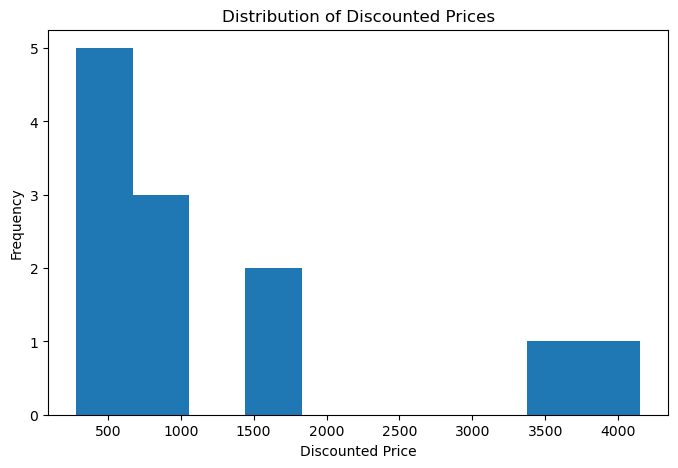

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["Discounted Price"], bins=10)
plt.title("Distribution of Discounted Prices")
plt.xlabel("Discounted Price")
plt.ylabel("Frequency")
plt.show()

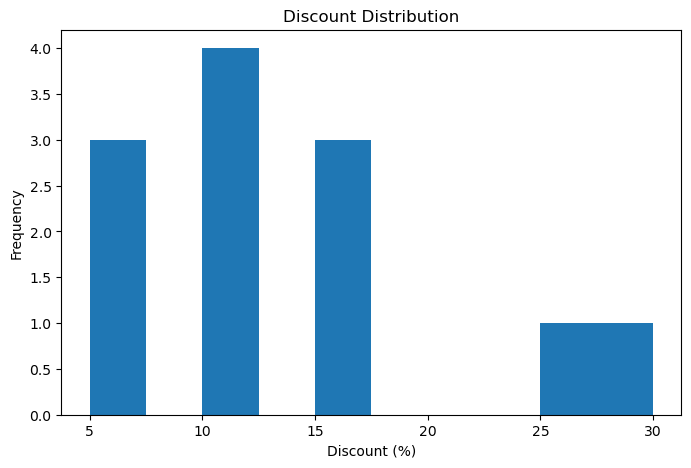

In [82]:
plt.figure(figsize=(8,5))
plt.hist(df["Discount"], bins=10)
plt.title("Discount Distribution")
plt.xlabel("Discount (%)")
plt.ylabel("Frequency")
plt.show()

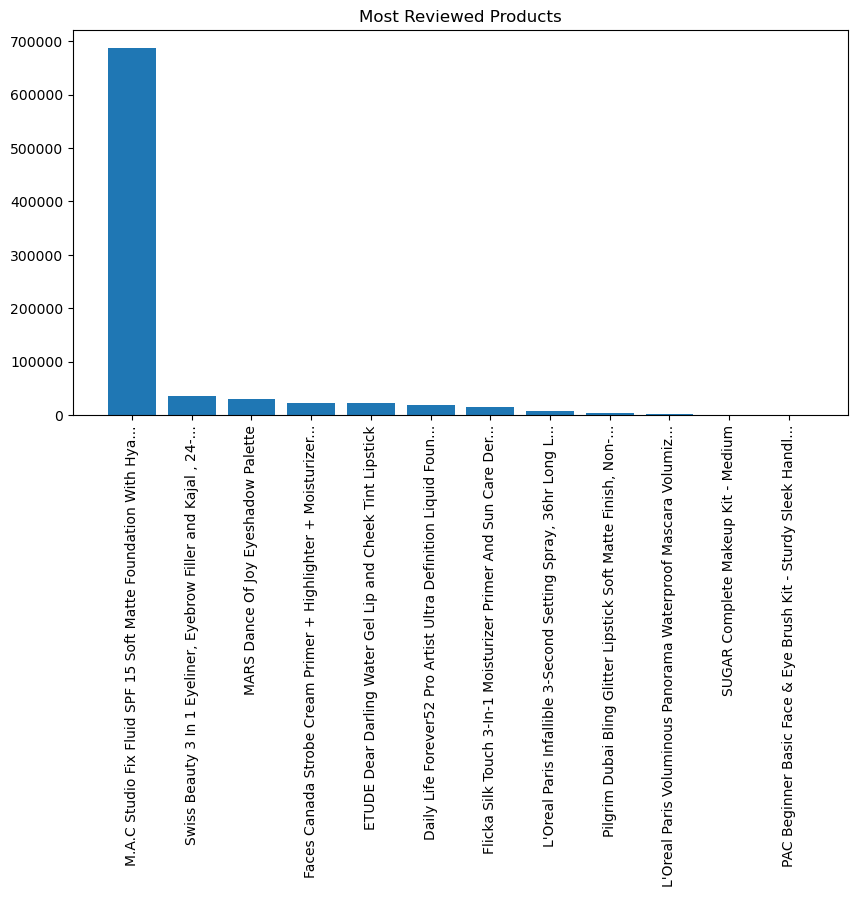

In [83]:
top_reviews = df.sort_values("Reviews", ascending=False)

plt.figure(figsize=(10,5))
plt.bar(top_reviews["Product Name"], top_reviews["Reviews"])
plt.xticks(rotation=90)
plt.title("Most Reviewed Products")
plt.show()

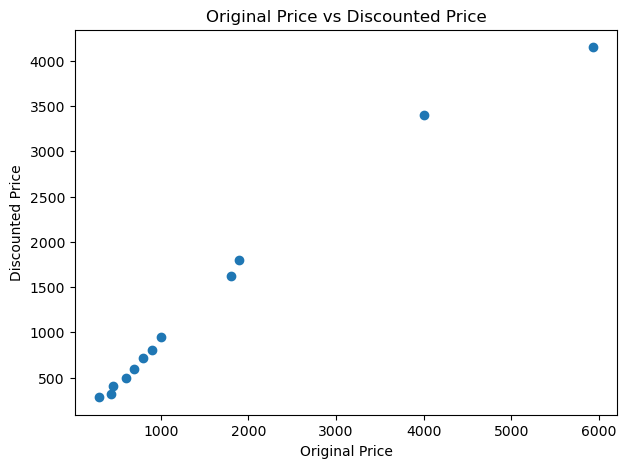

In [84]:
plt.figure(figsize=(7,5))
plt.scatter(df["Original Price"], df["Discounted Price"])
plt.xlabel("Original Price")
plt.ylabel("Discounted Price")
plt.title("Original Price vs Discounted Price")
plt.show()

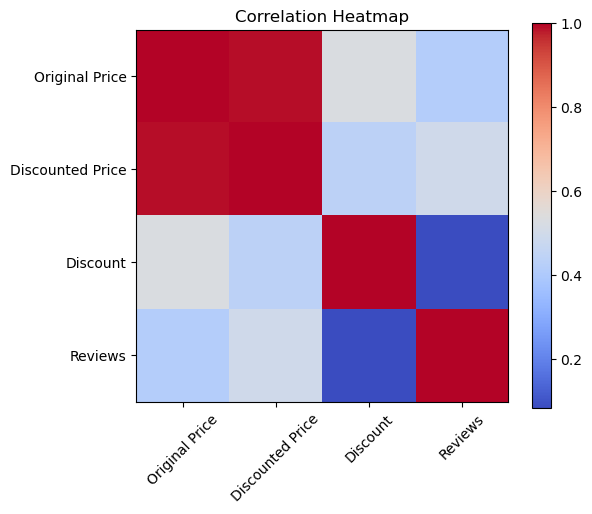

In [85]:
import matplotlib.pyplot as plt

corr = df[["Original Price","Discounted Price","Discount","Reviews"]].corr()

plt.figure(figsize=(6,5))
plt.imshow(corr, cmap="coolwarm")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.colorbar()
plt.title("Correlation Heatmap")
plt.show()

In [4]:
import pandas as pd

data = {
    "Product Name": product_names,
    "Original Price": original_prices,
    "Discounted Price": discounted_prices,
    "Discount": discounts,
    "Reviews": reviews
}

df = pd.DataFrame(data)

df.to_excel(r"NYKA-DATA-ANALYSIS/ NOTE BOOK/beauty_prod.csv") index=False

SyntaxError: invalid syntax (2649079050.py, line 13)